# Fase 1 — Comparação das metodologias

Três metodologias foram testadas na régua idêntica: mesmo split temporal, mesma métrica RMSSE, mesma proibição de preço, mesma tradução em reais.

| trilha | método | papel no argumento | notebook |
|---|---|---|---|
| **A** | Regressão linear | piso e diagnóstico do dado | [05](05_fase1a_regressaoLinear.ipynb) |
| **B** | Gradient Boosting | resposta às interações que a A mediu | [06](06_fase1b_gradientBoosting.ipynb) |
| **C** | MLP + *embeddings* | resposta à cardinalidade que o *one-hot* não resolveu | [07](07_fase1c_redeNeural.ipynb) |

A ordem não é cronológica: cada trilha responde a uma medição feita na anterior. Este notebook não treina nada — carrega as previsões salvas em `resultados/` e as compara.

## 1. Precisão

RMSSE no mesmo teste (últimos 120 dias), contra os mesmos benchmarks.

+-----------------------+---------+-------+
| modelo                |   RMSSE |   MAE |
+=======================+=========+=======+
| naïve (lag 1)         |  0.9542 | 39.64 |
+-----------------------+---------+-------+
| naïve sazonal (lag 7) |  1.0252 | 42.78 |
+-----------------------+---------+-------+
| média do SKU          |  0.7967 | 34.04 |
+-----------------------+---------+-------+
| A · Regressão linear  |  0.6488 | 27.12 |
+-----------------------+---------+-------+
| B · Gradient Boosting |  0.6094 | 25.39 |
+-----------------------+---------+-------+
| C · MLP + embeddings  |  0.6126 | 25.52 |
+-----------------------+---------+-------+


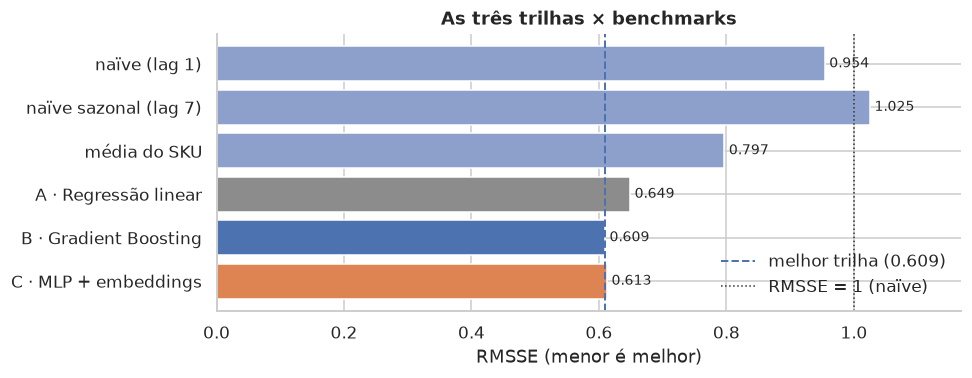

In [1]:
import warnings; warnings.filterwarnings("ignore")
import json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import fase1_comum as C

sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110; plt.rcParams["axes.titleweight"] = "bold"

df = C.carregar(); treino, teste = C.split(df)
base = C.baseline_atual(df, teste)

TRILHAS = [("A · Regressão linear", "A_regressaoLinear", "#8C8C8C"),
           ("B · Gradient Boosting", "B_gradientBoosting", "#4C72B0"),
           ("C · MLP + embeddings", "C_redeNeural", "#DD8452")]

# Placar de benchmarks (mesma régua) + RMSSE de cada trilha, recalculado das previsões salvas
placar = C.benchmarks(treino, teste)
linhas = []
preds, rmsse_trilha = {}, {}
for nome, arq, _ in TRILHAS:
    r = pd.read_csv(f"resultados/{arq}.csv", parse_dates=["data"])
    preds[nome] = r
    rmsse_trilha[nome] = round(C.rmsse_medio(r, "pred", treino), 4)
    linhas.append({"modelo": nome, "RMSSE": rmsse_trilha[nome],
                   "MAE": round((r["demanda"] - r["pred"]).abs().mean(), 2)})
placar = pd.concat([placar, pd.DataFrame(linhas)], ignore_index=True)
print(placar.to_markdown(index=False, tablefmt="grid"))

fig, ax = plt.subplots(figsize=(9, 3.6))
cor = ["#8DA0CB"]*3 + [c for _, _, c in TRILHAS]
b = ax.barh(placar["modelo"], placar["RMSSE"], color=cor)
ax.bar_label(b, fmt="%.3f", padding=3, fontsize=9)
melhor = placar["RMSSE"].min()
ax.axvline(melhor, color="#4C72B0", lw=1.3, ls="--", label=f"melhor trilha ({melhor:.3f})")
ax.axvline(1.0, color="#333", lw=1, ls=":", label="RMSSE = 1 (naïve)")
ax.set_xlabel("RMSSE (menor é melhor)"); ax.set_title("As três trilhas × benchmarks")
ax.invert_yaxis(); ax.legend(frameon=False, loc="lower right"); ax.margins(x=0.14)
sns.despine(); plt.tight_layout(); plt.show()

**Como ler.** As três primeiras barras são os benchmarks; as três seguintes, as trilhas, na ordem em que foram construídas. A linha tracejada marca a melhor trilha. Como **menor é melhor**, o que interessa é o tamanho dos degraus entre barras vizinhas — e não o valor absoluto de cada uma.

O ordenamento tem três degraus, e o primeiro é o maior: a linear já bate todos os benchmarks (0,649 contra 0,797 da média do SKU). Modelar o contexto do dia, e não o passado da série, produz a maior parte do ganho.

O segundo degrau é o do gradient boosting (0,609), que ganha 6% da linear. Não é um ganho genérico de modelo melhor: é o que a Trilha A previu ao medir em 3,6% o valor de **uma única** interação escrita à mão.

O terceiro degrau não existe. A MLP empata (0,613), porque a Trilha A já mostrara que a identidade do item não carrega sinal — não havia o que os *embeddings* destravassem.

## 2. Dinheiro

Cada previsão vira pedido pelo mesmo método — calibração de resíduos por SKU — e é avaliada no nível Médio (serviço 95%). Um modelo mais preciso precisa de menos estoque para o mesmo serviço, logo tem maior benefício líquido.

In [2]:
PRECO_REF = C.carregar().groupby("sku")["preco"].median()   # preço estável por SKU (mediana)

def calibra_no_teste(r, tau):
    "Pedido no nível τ por calibração de resíduos por SKU (in-sample no teste, igual para as 3 trilhas)."
    resid = (r["demanda"] - r["pred"]).groupby(r["sku"])
    add = r["sku"].map(resid.quantile(tau)).values
    return np.maximum(r["pred"].values + add, 0)

def economia_no_nivel(r, tau):
    pred = calibra_no_teste(r, tau)
    meia = r["sku"].map(C._reconstroi_meia_onda(df)).values
    preco = r["sku"].map(PRECO_REF).values
    ruptura = (r["demanda"].values > pred).mean()
    perda = (np.clip(r["demanda"].values - pred, 0, None) * preco).sum() / C.ANOS_TESTE
    capital = (pd.DataFrame({"data": r["data"].values, "v": (pred + meia) * preco})
               .groupby("data")["v"].sum().mean())
    return {"serviço": 1-ruptura, "ruptura": ruptura, "perda": perda, "capital": capital,
            "economia": base["perda"]-perda, "carreg": (capital-base["capital"])*C.CUSTO_CARREGAMENTO,
            "liquido": (base["perda"]-perda) - (capital-base["capital"])*C.CUSTO_CARREGAMENTO}

comp = []
for nome, arq, _ in TRILHAS:
    e = economia_no_nivel(preds[nome], C.NIVEIS["Médio"])
    comp.append({"trilha": nome, "RMSSE": rmsse_trilha[nome],
                 "serviço": f"{e['serviço']:.0%}", "ruptura": f"{e['ruptura']:.1%}",
                 "capital (R$ mi)": round(e["capital"]/1e6, 2),
                 "economia (R$ mi/ano)": round(e["economia"]/1e6, 2),
                 "benefício líq. (R$ mi/ano)": round(e["liquido"]/1e6, 2)})
comp = pd.DataFrame(comp)
print(f"Nível Médio (serviço 95%). Operação atual: ruptura {base['ruptura']:.1%}, "
      f"perda R$ {base['perda']/1e6:.1f} M/ano, capital R$ {base['capital']/1e6:.2f} M\n")
print(comp.to_markdown(index=False, tablefmt="grid"))

Nível Médio (serviço 95%). Operação atual: ruptura 13.3%, perda R$ 12.5 M/ano, capital R$ 1.92 M

+-----------------------+---------+-----------+-----------+-------------------+------------------------+------------------------------+
| trilha                |   RMSSE | serviço   | ruptura   |   capital (R$ mi) |   economia (R$ mi/ano) |   benefício líq. (R$ mi/ano) |
+=======================+=========+===========+===========+===================+========================+==============================+
| A · Regressão linear  |  0.6488 | 95%       | 5.0%      |              2.08 |                  10.53 |                        10.49 |
+-----------------------+---------+-----------+-----------+-------------------+------------------------+------------------------------+
| B · Gradient Boosting |  0.6094 | 95%       | 5.0%      |              2.07 |                  10.6  |                        10.57 |
+-----------------------+---------+-----------+-----------+-------------------+-------

Em dinheiro o quadro comprime a ponto de quase desaparecer: as três entregam 95% de serviço com o mesmo capital, e o benefício líquido vai de R\$ 10,49 M (linear) a R\$ 10,58 M (MLP). São **R\$ 80 mil/ano** separando o modelo mais simples do mais complexo — **99,2% do valor já está na Trilha A**.

A mecânica do pedido explica: qualquer modelo calibrado para 95% *atinge* 95% de serviço, e o que a acurácia muda é apenas quanto estoque ele precisa para chegar lá. Prever melhor economiza folga, não serviço.

Isso não é argumento contra modelar melhor — R\$ 80 mil/ano são recorrentes, e 6% de RMSSE é ganho legítimo. É argumento sobre de onde vem o valor: de mudar o alvo do pedido e alocar estoque nos itens certos, decisões que a Trilha A já tomava. Um projeto iniciado pelo boosting teria creditado ao modelo os R\$ 10,5 M que não são dele.

## 3. O quadro completo

Precisão, valor e custo de engenharia lado a lado.

In [3]:
quadro = pd.DataFrame({
    "critério": ["RMSSE (acurácia)", "benefício líquido (Médio)", "descobre interações?",
                 "custo de treino", "interpretável?", "o que entregou ao projeto", "veredito"],
    "A · Regressão linear": ["0,649", "R$ 10,49 M", "não (só escritas à mão)", "instantâneo",
                             "total (coeficientes)", "o diagnóstico e o piso", "🔍 INSTRUMENTO"],
    "B · Gradient Boosting": ["0,609 (melhor)", "R$ 10,57 M", "sim (automático)", "segundos",
                              "parcial (importância)", "a maior acurácia", "✅ ESCOLHA"],
    "C · MLP + embeddings": ["0,613 (empata)", "R$ 10,58 M", "sim (implícito)", "~1 min",
                             "difícil", "a confirmação do teto", "➖ empata, mais caro"],
})
print(quadro.to_markdown(index=False, tablefmt="grid"))

+---------------------------+-------------------------+-------------------------+------------------------+
| critério                  | A · Regressão linear    | B · Gradient Boosting   | C · MLP + embeddings   |
+===========================+=========================+=========================+========================+
| RMSSE (acurácia)          | 0,649                   | 0,609 (melhor)          | 0,613 (empata)         |
+---------------------------+-------------------------+-------------------------+------------------------+
| benefício líquido (Médio) | R$ 10,49 M              | R$ 10,57 M              | R$ 10,58 M             |
+---------------------------+-------------------------+-------------------------+------------------------+
| descobre interações?      | não (só escritas à mão) | sim (automático)        | sim (implícito)        |
+---------------------------+-------------------------+-------------------------+------------------------+
| custo de treino           | instant

## 4. Conclusões da fase 1

**1. Começar pela linear mudou o que o resto da fase significa.** Sem a Trilha A, o gradient boosting apareceria como o modelo que resolveu o problema. Com ela, sabe-se que resolveu 6% do problema de acurácia e 0,8% do de dinheiro — o resto já estava resolvido por modelar contexto e pedir quantil.

**2. Cada escolha de modelagem tem uma medida por trás.** Proibir o preço veio da decomposição que mostrou o desvio do dia valendo 37% de RMSSE; prever quantil veio de a média atender 51% dos dias; usar árvores veio do viés de 35 un./dia em `Clothing` × epidemia; testar *embeddings* veio de o *one-hot* de SKU não pagar suas 100 colunas.

**3. O gradient boosting vence, e a vitória tem o tamanho previsto.** A Trilha A estimou o valor das interações em 3,6% com um termo; o boosting, que descobre todas, extraiu 6%. Os números conversam.

**4. A rede neural iguala, não supera.** Os *embeddings* funcionam e encontram o mesmo teto. Seriam a escolha com muito mais dados ou cardinalidade realmente alta.

**5. O histórico não ajuda em nenhuma das três.** Coeficiente +0,10 na linear, *lags* sem ganho no boosting, autocorrelação 0,24. A demanda responde ao contexto do dia, o que explica por que a metodologia da M5 só transfere em parte.

**6. As três convergem para a mesma decisão de negócio.** Calibrada a 95%, qualquer uma recupera ~R$ 10,5–10,6 milhões/ano de benefício líquido com praticamente o capital de hoje, e τ oferece o mesmo botão de ajuste.

### Modelo entregue

> **Gradient Boosting global** (Trilha B), prevendo o quantil da demanda por SKU-dia, com preditores honestos. A rede neural foi testada e não justificou substituí-lo. A regressão linear permanece como modelo de referência e ferramenta de diagnóstico, não como candidato a produção.

### Próximos passos

O modelo está escolhido, mas seus **hiperparâmetros** foram fixados à mão e nunca justificados. É o que a [fase 2](09_fase2_hiperparametros.ipynb) mede, sob validação em origem deslizante.

Ficam registradas duas linhas não perseguidas: *ensemble* leve B+C, que na M5 rendeu ganho pequeno mas real, e *pinball loss* nativa na rede em vez de calibração de resíduos.